In [2]:


import os
import sys

current_dir = os.getcwd()
project_root = current_dir[:current_dir.find("src") - 1]
sys.path.insert(0, project_root)


In [3]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

from src.models.train_model.train_model import *
from sklearn.model_selection import train_test_split


In [4]:
merged_df_path = os.path.join(project_root, "data", "processed", "joined_df.csv")
merged_df = pd.read_csv(merged_df_path, encoding='utf-8')

power_plants = merged_df[['name', 'code']].drop_duplicates()
power_plants = power_plants[power_plants['code'].str.startswith("G")]

In [5]:
power_plants

,name,code
0,پرند,G16
1,پرند,G14
192,پرند,G12
193,پرند,G13
194,پرند,G11
1765,پرند,G15
81288,شهدای پیروز - بهبهان,G12
94478,شهدای پیروز - بهبهان,G11
104408,جنوب اصفهان - چهلستون,G15
104409,جنوب اصفهان - چهلستون,G14


In [6]:
def find_95_max(array):
    array = np.array(array)
    sorted_array = np.sort(array)
    idx = int(len(array) * 0.95)
    return sorted_array[idx]

In [7]:
i = 0
row = power_plants.iloc[i]
name = row['name']
code = row['code']
one_unit_df = merged_df[(merged_df['name'] == name) & (merged_df['code'] == code)]
one_unit_df = one_unit_df[one_unit_df['is_good_peak'] >= 3]

name, code

('پرند', 'G16')

In [8]:
senstemps = one_unit_df['sen_temperature'].values
gens = one_unit_df['generation'].values


In [9]:
hist, bin_edges = np.histogram(senstemps, bins=101)
group_indices = np.digitize(senstemps, bin_edges) - 1
tuples = []


for g in np.unique(group_indices):
    mask = group_indices == g
    tuples.append((senstemps[mask].mean(), find_95_max(gens[mask])))


In [10]:
X = np.array([a for a, b in tuples]).reshape(-1, 1)
y = np.array([b for a, b in tuples])
model = LinearRegression()
model.fit(X, y)


X_all = senstemps.reshape(-1, 1)
y_pred_all = model.predict(X_all)

alpha = 2
beta = 5
is_in_area = (y_pred_all + alpha >= gens) & (gens >= y_pred_all - beta)

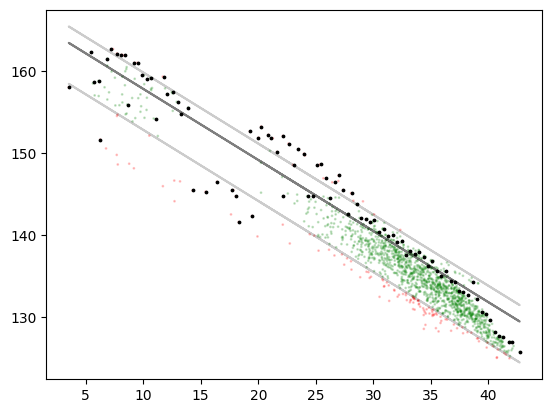

In [11]:
colors = ['green' if val else 'red' for val in is_in_area]

plt.scatter(senstemps, gens, s=1, alpha=0.2, color = colors)
plt.plot(X_all, y_pred_all, color="black", alpha = 0.5)
plt.plot(X_all, y_pred_all + alpha, color="black", alpha = 0.2)
plt.plot(X_all, y_pred_all - beta, color="black", alpha = 0.2)
plt.scatter(X, y, s=3, color='black')
plt.show()

In [12]:
one_unit_df.loc[is_in_area, "is_good_peak"] = 4


In [30]:
df_r_selected = Data_selector(one_unit_df).select_peaks(goodness=4)

base_features = ["temperature", "humidity", "dew", "surface_pressure"]
# base_features = []
hours_delay = [1, 5]
lag_features = [f"{feature}_with_{hour}_delay" for feature in base_features for hour in hours_delay]
time_features = ["hour", "day_of_week", "month", "season", "datetime"]
feature_selector = Feature_selector(df_r_selected, "generation")

features_to_select = base_features + lag_features + time_features + ["sen_temperature"]
# features_to_select = ["sen_temperature", 'datetime']
feature_selector.select(features_to_select=features_to_select)
X, y, _ = feature_selector.get_X_and_y(n_mimo=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=2000, max_depth=5, learning_rate=0.1)
# model = LinearRegression()
model.fit(X_train, y_train)
logger.info(f"Model has been trained successfully")

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

rmse_error_train = compute_relative_rmse(y_pred_train, y_train)
rmse_error_test = compute_relative_rmse(y_pred_test, y_test)

logger.info(f"Train rmse error: {rmse_error_train:0.3f}%")
logger.info(f"Test rmse error: {rmse_error_test:0.3f}%")


2025-10-05 18:05:31 - train_model - INFO - Model has been trained successfully
2025-10-05 18:05:31 - train_model - INFO - Train rmse error: 0.001%
2025-10-05 18:05:31 - train_model - INFO - Test rmse error: 0.606%


In [31]:
model.feature_importances_

array([0.00496321, 0.00143122, 0.00173348, 0.00183207, 0.00276308,
       0.23406845, 0.00215959, 0.00237991, 0.00306103, 0.00402147,
       0.00195726, 0.01099735, 0.00543818, 0.00367856, 0.01266856,
       0.6382856 , 0.04637922, 0.01394384, 0.00823802], dtype=float32)

In [28]:

features_to_select.remove("datetime")

In [32]:
for coef, feature in zip(model.feature_importances_, X.columns):
    print(coef, feature)

0.004963206 temperature
0.0014312236 humidity
0.0017334834 dew
0.0018320683 surface_pressure
0.0027630785 temperature_with_1_delay
0.23406845 temperature_with_5_delay
0.0021595855 humidity_with_1_delay
0.002379913 humidity_with_5_delay
0.003061035 dew_with_1_delay
0.00402147 dew_with_5_delay
0.001957259 surface_pressure_with_1_delay
0.010997346 surface_pressure_with_5_delay
0.005438182 hour
0.0036785563 day_of_week
0.012668564 month
0.6382856 sen_temperature
0.046379223 season_spring
0.013943842 season_summer
0.008238022 season_winter


In [55]:
y_diff = y_pred_test - y_test

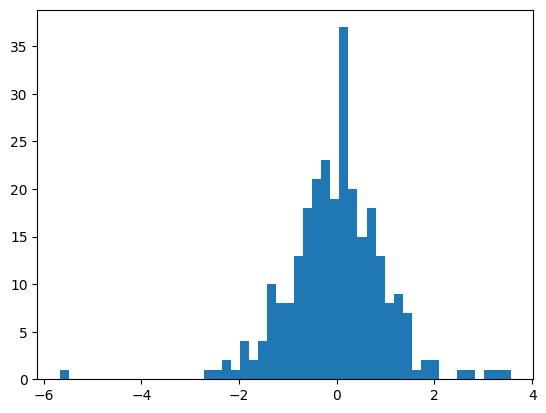

In [56]:
plt.hist(y_diff, bins=50)
plt.show()

In [57]:
a_one_unit_df = merged_df[(merged_df['name'] == name) & (merged_df['code'] == code)]

df_r_selected = Data_selector(a_one_unit_df).select_peaks(goodness=0)

base_features = ["temperature", "humidity", "dew", "surface_pressure"]
# base_features = []
hours_delay = [1, 5]
lag_features = [f"{feature}_with_{hour}_delay" for feature in base_features for hour in hours_delay]
time_features = ["hour", "day_of_week", "month", "season", "datetime"]
feature_selector = Feature_selector(df_r_selected, "generation")

features_to_select = base_features + lag_features + time_features + ["sen_temperature"]
# features_to_select = ["sen_temperature", 'datetime']

feature_selector.select(features_to_select=features_to_select)
X, y, _ = feature_selector.get_X_and_y(n_mimo=1)

y_pred_my_all = model.predict(X)

In [58]:
merged_df.loc[y.index, "prediction"] = y_pred_my_all

In [59]:
write_df_path = os.path.join(project_root, "data", "processed", "data_for_plot.csv")
merged_df.to_csv(write_df_path)